In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [8]:
df = pd.read_csv(r"C:\Users\LOQ\OneDrive\Desktop\UberDriver\ncr_ride_bookings.csv")
print(df.head())

         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...         

In [9]:
print(df.shape)
print(df.info())
print(df.isnull().sum())


(150000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10

In [10]:
df = df.replace('"', '', regex=True)

In [12]:
print(df.columns)

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='str')


In [13]:
# Fill numerical columns correctly

df['Ride Distance'] = df['Ride Distance'].fillna(df['Ride Distance'].mean())

df['Booking Value'] = df['Booking Value'].fillna(df['Booking Value'].mean())

df['Customer Rating'] = df['Customer Rating'].fillna(df['Customer Rating'].median())

df['Driver Ratings'] = df['Driver Ratings'].fillna(df['Driver Ratings'].median())

# Optional columns
df['Avg VTAT'] = df['Avg VTAT'].fillna(df['Avg VTAT'].mean())
df['Avg CTAT'] = df['Avg CTAT'].fillna(df['Avg CTAT'].mean())

In [14]:
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day_name()
df = df.dropna(subset=['datetime'])


In [15]:
df['is_cancelled'] = df['Booking Status'].apply(
    lambda x: 0 if x == 'Completed' else 1
)

In [17]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [18]:
cols_to_drop = [
    'Date', 'Time',
    'Cancelled_Rides_by_Customer',
    'Cancelled_Rides_by_Driver',
    'Incomplete_Rides',
    'Incomplete_Rides_Reason',
    'Reason_for_cancelling_by_Customer',
    'Driver_Cancellation_Reason'
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [20]:
cols_to_drop = [
    'Booking_ID',
    'Customer_ID',
    'Pickup_Location',
    'Drop_Location'
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [21]:
categorical_cols = [
    'Vehicle_Type',
    'Payment_Method',
    'Booking_Status'
]

# Keep only existing columns
categorical_cols = [col for col in categorical_cols if col in df.columns]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [22]:
print(df.shape)

(150000, 24)


In [23]:
print(df.head())

    Avg_VTAT   Avg_CTAT  Booking_Value  Ride_Distance  Driver_Ratings  \
0   8.456352  29.149636     508.295912      24.637012             4.3   
1   4.900000  14.000000     237.000000       5.730000             4.3   
2  13.400000  25.800000     627.000000      13.580000             4.9   
3  13.100000  28.500000     416.000000      34.020000             4.6   
4   5.300000  19.600000     737.000000      48.210000             4.1   

   Customer_Rating            datetime  hour       day  is_cancelled  ...  \
0              4.5 2024-03-23 12:29:38    12  Saturday             1  ...   
1              4.5 2024-11-29 18:01:39    18    Friday             1  ...   
2              4.9 2024-08-23 08:56:10     8    Friday             0  ...   
3              5.0 2024-10-21 17:17:25    17    Monday             0  ...   
4              4.3 2024-09-16 22:08:00    22    Monday             0  ...   

   Vehicle_Type_Uber XL  Vehicle_Type_eBike  Payment_Method_Credit Card  \
0                 False

In [24]:
print(df.columns)

Index(['Avg_VTAT', 'Avg_CTAT', 'Booking_Value', 'Ride_Distance',
       'Driver_Ratings', 'Customer_Rating', 'datetime', 'hour', 'day',
       'is_cancelled', 'Vehicle_Type_Bike', 'Vehicle_Type_Go Mini',
       'Vehicle_Type_Go Sedan', 'Vehicle_Type_Premier Sedan',
       'Vehicle_Type_Uber XL', 'Vehicle_Type_eBike',
       'Payment_Method_Credit Card', 'Payment_Method_Debit Card',
       'Payment_Method_UPI', 'Payment_Method_Uber Wallet',
       'Booking_Status_Cancelled by Driver', 'Booking_Status_Completed',
       'Booking_Status_Incomplete', 'Booking_Status_No Driver Found'],
      dtype='str')


In [40]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')


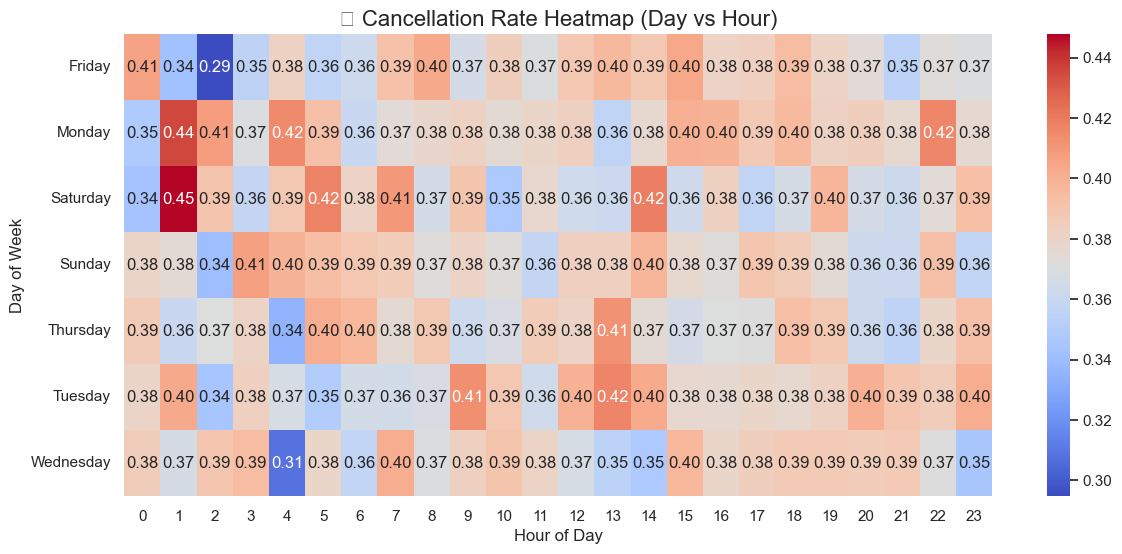

In [48]:

pivot = df.pivot_table(values='is_cancelled', index='day', columns='hour', aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("🔥 Cancellation Rate Heatmap (Day vs Hour)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

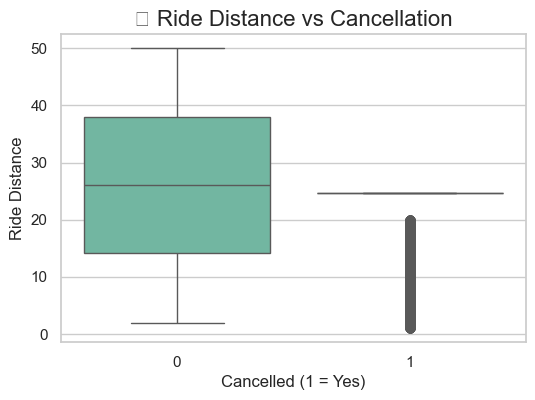

In [69]:
plt.figure(figsize=(6,4))
sns.boxplot(x='is_cancelled', y='Ride_Distance', data=df, palette='Set2')
plt.title("📦 Ride Distance vs Cancellation", fontsize=16)
plt.xlabel("Cancelled (1 = Yes)")
plt.ylabel("Ride Distance")
plt.show()

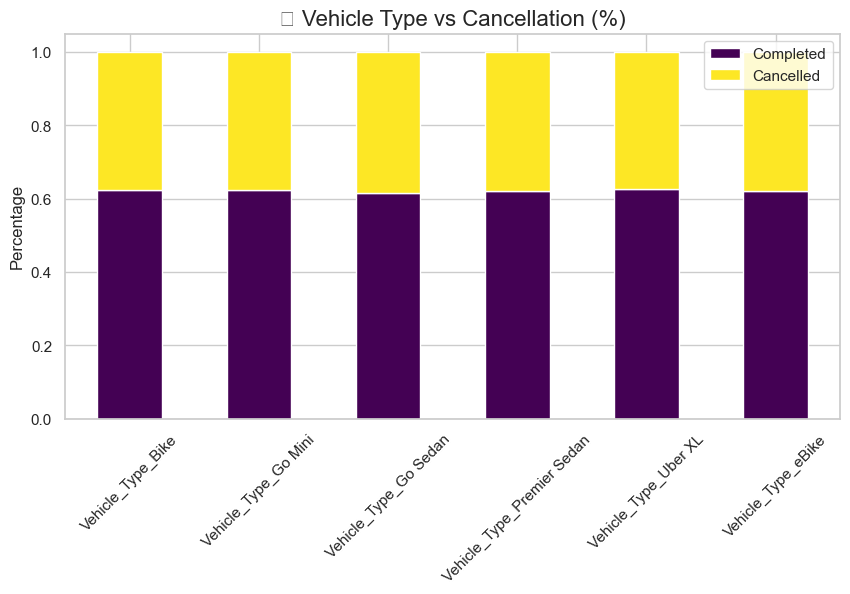

In [66]:
vehicle_cols = [col for col in df.columns if 'Vehicle_Type' in col]

vehicle_cancel = df.groupby('is_cancelled')[vehicle_cols].sum().T
vehicle_cancel = vehicle_cancel.div(vehicle_cancel.sum(axis=1), axis=0)

vehicle_cancel.plot(kind='bar', stacked=True, figsize=(10,5), colormap='viridis')
plt.title("🚗 Vehicle Type vs Cancellation (%)", fontsize=16)
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(["Completed", "Cancelled"])
plt.show()

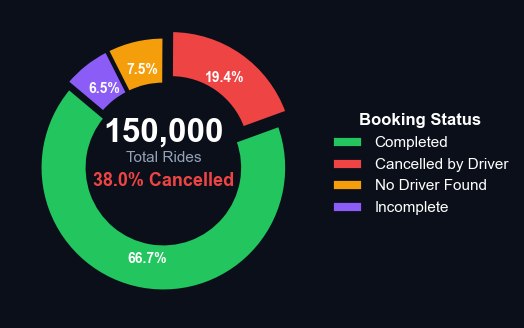

In [57]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor='#0b0f19')
ax.set_facecolor('#0b0f19')
status_cols = [col for col in df.columns if 'Booking_Status' in col]
status = df[status_cols].sum().sort_values(ascending=False)
status.index = status.index.str.replace('Booking_Status_', '')
color_map = {
    'Completed': '#22c55e',            # green
    'Cancelled by Driver': '#ef4444',  # strong red
    'Cancelled by Customer': '#fb7185',
    'No Driver Found': '#f59e0b',      # amber
    'Incomplete': '#8b5cf6'            # purple
}

colors = [color_map.get(i, '#38bdf8') for i in status.index]
explode = [0.1 if 'Cancelled' in i else 0.03 for i in status.index]
wedges, _, autotexts = ax.pie(
    status.values,
    labels=None,
    colors=colors,
    startangle=140,
    autopct='%1.1f%%',
    pctdistance=0.75,
    explode=explode,
    wedgeprops=dict(width=0.38, edgecolor='#0b0f19', linewidth=2)
)

# Style percentages
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(10)
    at.set_fontweight('bold')

#Center KPI (clean spacing)
total = len(df)
cancel_rate = df['is_cancelled'].mean() * 100

ax.text(0, 0.18, f'{total:,}',
        ha='center', fontsize=24,
        color='white', fontweight='bold')

ax.text(0, 0.02, 'Total Rides',
        ha='center', fontsize=11,
        color='#94a3b8')

ax.text(0, -0.18, f'{cancel_rate:.1f}% Cancelled',
        ha='center', fontsize=13,
        color='#ef4444', fontweight='bold')

#Clean legend (right side)
legend = ax.legend(
    wedges,
    status.index,
    title="Booking Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

#Make legend text WHITE
plt.setp(legend.get_texts(), color='white', fontsize=11)

#Make legend title WHITE
legend.get_title().set_color('white')
legend.get_title().set_fontsize(12)
legend.get_title().set_fontweight('bold')
plt.show()

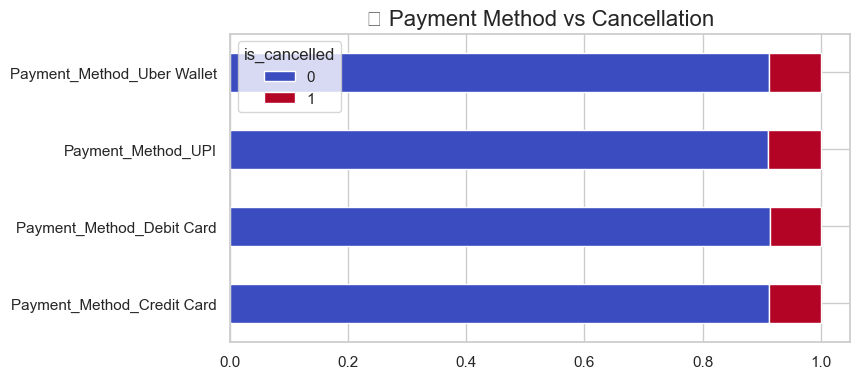

In [64]:
payment_cols = [col for col in df.columns if 'Payment_Method' in col]

payment_cancel = df.groupby('is_cancelled')[payment_cols].sum().T
payment_cancel = payment_cancel.div(payment_cancel.sum(axis=1), axis=0)

payment_cancel.plot(kind='barh', stacked=True, figsize=(8,4), colormap='coolwarm')
plt.title("Payment Method vs Cancellation", fontsize=16)
plt.show()

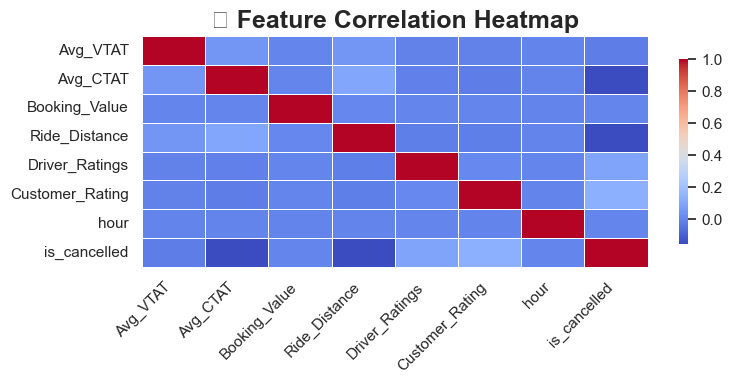

In [65]:
plt.figure(figsize=(8,4))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title("🧠 Feature Correlation Heatmap",
          fontsize=18, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [70]:
# Select only numeric features
X = df.select_dtypes(include=['number']).drop('is_cancelled', axis=1)
y = df['is_cancelled']

# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [71]:
def predict_cancellation(input_data):
    import numpy as np
    
    input_array = np.array(input_data).reshape(1, -1)
    
    prediction = model.predict(input_array)
    probability = model.predict_proba(input_array)[0][1]
    
    return prediction[0], probability

In [72]:
#TESTING 
sample = X.iloc[0].values

pred, prob = predict_cancellation(sample)

print("Prediction:", pred)
print("Probability:", prob)

Prediction: 1
Probability: 1.0


In [73]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X)
print("Accuracy:", accuracy_score(y, y_pred))

Accuracy: 1.0


In [75]:
#!pip install streamlit
